## 1.Big Data분석기초_연습_04_탐색적분석_확률, 통계_안나경

In [10]:
# 데이터 구성 패키지: Series, DataFrame
import pandas as pd
# 행렬 연산 패키지
import numpy as np

# 데이터 시각화 패키지
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석 패키지
from scipy import stats
import scipy.stats

In [11]:
# 한글 폰트(맑은 고딕) 적용 : 윈도우, 구글 콜랩
matplotlib.rc("font", family = "Malgun Gothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [12]:
# 실행결과 경고메시지 출력 제외
import warnings
warnings.filterwarnings('ignore')

### 연습

In [13]:
# mycars 데이터 가져오기
mycars = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\mycars.csv")
mycars.head()

,manufacturer,model,displacement,year,cylinder,automatic,driving,mpg,highway_mileage,fuel,class
0,audi,a4,1.8,1999,4,auto,f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual,f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual,f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto,f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto,f,16,26,p,compact


In [14]:
# 1. 시내에서 연비(mpg) 통계치 : 기술통계량   
mycars.describe().round(2)


,displacement,year,cylinder,mpg,highway_mileage
count,234.00,234.00,234.00,234.00,234.00
mean,3.47,2003.50,5.89,16.86,23.44
std,1.29,4.51,1.61,4.26,5.95
min,1.60,1999.00,4.00,9.00,12.00
25%,2.40,1999.00,4.00,14.00,18.00
50%,3.30,2003.50,6.00,17.00,24.00
75%,4.60,2008.00,8.00,19.00,27.00
max,7.00,2008.00,8.00,35.00,44.00


In [15]:
# 2. 자동차 모델별, mpg별 통계치 : 모델별 mpg 데이터 subset
df = mycars[['model','mpg']]
df.head()

,model,mpg
0,a4,18
1,a4,21
2,a4,20
3,a4,21
4,a4,16


In [16]:
# 자동차 모델별, mpg  기술통계량
df.groupby('model').describe()

mpg                                                 \
                       count       mean       std   min    25%   50%    75%   
model                                                                         
4runner 4wd              6.0  15.166667  0.752773  14.0  15.00  15.0  15.75   
a4                       7.0  18.857143  1.864454  16.0  18.00  18.0  20.50   
a4 quattro               8.0  17.125000  1.807722  15.0  15.75  17.0  18.25   
a6 quattro               3.0  16.000000  1.000000  15.0  15.50  16.0  16.50   
altima                   6.0  20.666667  1.966384  19.0  19.00  20.0  22.50   
c1500 suburban 2wd       5.0  12.800000  1.303840  11.0  12.00  13.0  14.00   
camry                    7.0  19.857143  1.463850  18.0  18.50  21.0  21.00   
camry solara             7.0  19.857143  1.772811  18.0  18.00  21.0  21.00   
caravan 2wd             11.0  15.818182  1.834022  11.0  15.50  16.0  17.00   
civic                    9.0  24.444444  1.943651  21.0  24.00  24.0  25.00   
corolla                  5.0  25.600000  1.673320  24.0  24.00  26.0  26.00   
corvette                 5.0  15.400000  0.547723  15.0  15.00  15.0  16.00   
dakota pickup 4wd        9.0  12.777778  1.986063   9.0  11.00  14.0  14.00   
durango 4wd              7.0  11.857143  1.573592   9.0  11.00  13.0  13.00   
expedition 2wd           3.0  11.333333  0.577350  11.0  11.00  11.0  11.50   
explorer 4wd             6.0  13.666667  0.816497  13.0  13.00  13.5  14.00   
f150 pickup 4wd          7.0  13.000000  1.000000  11.0  13.00  13.0  13.50   
forester awd             6.0  18.833333  0.983192  18.0  18.00  18.5  19.75   
grand cherokee 4wd       8.0  13.500000  2.507133   9.0  12.50  14.0  15.00   
grand prix               5.0  17.000000  1.000000  16.0  16.00  17.0  18.00   
gti                      5.0  20.000000  2.000000  17.0  19.00  21.0  21.00   
impreza awd              8.0  19.625000  0.744024  19.0  19.00  19.5  20.00   
jetta                    9.0  21.222222  4.867694  16.0  19.00  21.0  21.00   
k1500 tahoe 4wd          4.0  12.500000  1.732051  11.0  11.00  12.5  14.00   
land cruiser wagon 4wd   2.0  12.000000  1.414214  11.0  11.50  12.0  12.50   
malibu                   5.0  18.800000  1.923538  17.0  18.00  18.0  19.00   
maxima                   3.0  18.666667  0.577350  18.0  18.50  19.0  19.00   
mountaineer 4wd          4.0  13.250000  0.500000  13.0  13.00  13.0  13.25   
mustang                  9.0  15.888889  1.452966  14.0  15.00  15.0  17.00   
navigator 2wd            3.0  11.333333  0.577350  11.0  11.00  11.0  11.50   
new beetle               6.0  24.000000  6.511528  19.0  20.00  20.5  27.00   
passat                   7.0  18.571429  1.902379  16.0  17.50  18.0  20.00   
pathfinder 4wd           4.0  13.750000  1.258306  12.0  13.50  14.0  14.25   
ram 1500 pickup 4wd     10.0  11.400000  1.505545   9.0  11.00  11.5  12.75   
range rover              4.0  11.500000  0.577350  11.0  11.00  11.5  12.00   
sonata                   7.0  19.000000  1.414214  18.0  18.00  18.0  20.00   
tiburon                  7.0  18.285714  1.603567  16.0  17.00  19.0  19.50   
toyota tacoma 4wd        7.0  15.571429  0.786796  15.0  15.00  15.0  16.00   

                              
                         max  
model                         
4runner 4wd             16.0  
a4                      21.0  
a4 quattro              20.0  
a6 quattro              17.0  
altima                  23.0  
c1500 suburban 2wd      14.0  
camry                   21.0  
camry solara            22.0  
caravan 2wd             18.0  
civic                   28.0  
corolla                 28.0  
corvette                16.0  
dakota pickup 4wd       15.0  
durango 4wd             13.0  
expedition 2wd          12.0  
explorer 4wd            15.0  
f150 pickup 4wd         14.0  
forester awd            20.0  
grand cherokee 4wd      17.0  
grand prix              18.0  
gti                     22.0  
impreza awd             21.0  
jetta     

In [17]:
# D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\EXH_QC1.csv

## 연습

In [18]:
#  Exh_QC1 데이터 가져오기
QC1 = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\EXH_QC1.csv")
QC1.head()

,Flaws,Period,Strength,Baking Time,Cabbage weight
0,Scratch,Day,37.6,0.798922,3.6
1,Scratch,Day,38.6,0.849020,2.9
2,Peel,Day,37.2,0.816163,2.8
3,Peel,Day,36.4,0.758266,2.6
4,Smudge,Day,38.6,0.815894,3.4


In [19]:
# 제품 결함과 결함이 발생한 기간의 데이터 subset
df = QC1[['Flaws', 'Period']]

In [20]:
# Flaws 변수 Count: value_counts(), 순서대로 정렬: .sort_index()
count = df['Flaws'].value_counts().sort_index()
count

Other       6
Peel       15
Scratch    13
Smudge      6
Name: Flaws, dtype: int64

# 9번 연습

In [21]:
n = 3
p = 0.4

for i in range(n+1) :
    prob = stats.binom.pmf(k=i, n=n, p=p)  
    print("P(X={0})= {1:.3f}".format(i, prob))

P(X=0)= 0.216
P(X=1)= 0.432
P(X=2)= 0.288
P(X=3)= 0.064


### 어라

In [22]:
n = 5
p = 0.3

for i in range(n+1) :
    prob = stats.binom.pmf(k=i, n=n, p=p)  
    print("P(X={0})= {1:.3f}".format(i, prob))

P(X=0)= 0.168
P(X=1)= 0.360
P(X=2)= 0.309
P(X=3)= 0.132
P(X=4)= 0.028
P(X=5)= 0.002


In [25]:
!pip install statsmodels

In [26]:
# 가설검정 및 통계 분석 패키지
import scipy.stats as stats
from statsmodels.formula.api import ols

# proportion test 패키지
from statsmodels.stats.proportion import proportions_ztest

# ANOVA 분석 패키지
from statsmodels.stats.anova import anova_lm

In [27]:
# camshaft 데이터 가져오기
df = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\camshaft.csv")
df.head()

,Length,Supp1,Supp2
0,601.4,598.0,601.6
1,601.6,599.8,600.4
2,598.0,600.0,598.4
3,601.4,599.8,600.0
4,599.4,600.0,596.8


In [28]:
# 정규성 검정 : Shapiro-Wilk Test
statistic, p = stats.shapiro(df['Supp1'])

print("Shapiro-Wilk Test: statistic={}, p-value={}".format(statistic, p))

Shapiro-Wilk Test: statistic=0.9788166105638217, p-value=0.10745975471220626


# 모평균 예제

정규성 검정결과(95%신뢰수준 사용시) p-value가 0.05보다 크므로 정규분포를 따른다 할 수 있다.

In [29]:
# 데이터 직접입력
df = pd.DataFrame({'wgt':[3.6, 2.9, 2.8, 2.6, 3.4, 3.2, 2.2, 2.6, 
                          2.6, 2.4, 2.4, 2.6, 3.4, 2.4, 2.1, 2.6, 
                          3.0, 2.4, 2.7, 2.4, 2.6, 2.9, 2.9, 2.0, 
                          2.7, 2.2, 2.8, 2.7, 1.8, 2.5, 3.0, 3.2, 
                          2.8, 2.6, 3.2, 3.1, 2.9, 2.7, 2.7, 2.2]})
df.head()

,wgt
0,3.6
1,2.9
2,2.8
3,2.6
4,3.4


In [30]:
# 정규분포 구간 추정 함수 실행 

lower, upper = stats.norm.interval(0.95, loc = np.mean(df), scale = 0.397/np.sqrt(40))
print("신뢰구간: ({0}, {1})" .format(lower.round(2), upper.round(2)))

신뢰구간: ([2.57], [2.82])


In [35]:
# df를 직접 입력 
df = pd.DataFrame({'streng':[54.1, 53.3, 56.1, 55.7, 54.0, 54.1, 54.5, 
                             57.1, 55.2, 53.8, 54.1, 54.1, 56.1, 55.0, 
                             55.9, 56.0, 54.9, 54.3, 53.9, 55.0]})
df.head()

,streng
0,54.1
1,53.3
2,56.1
3,55.7
4,54.0


In [36]:
df.mean()

streng    54.86
dtype: float64

In [32]:
# t 분포 구간추정 함수 실행 : (loc: 평균의 값, scale: 변동 정도)  
lower, upper = stats.t.interval(0.95, len(df)-1, loc = np.mean(df), scale = stats.sem(df))
lower.round(2), upper.round(2)

(array([54.39]), array([55.33]))

- 1-Sample t-test : 모표준편차를 모를 때

In [33]:
# df를 직접 입력 
df = pd.DataFrame({'satisfaction': [74.5, 81.2, 73.8, 82.0, 76.3, 75.7, 80.2, 72.6, 
                                    77.9, 82.8]})
df.head()

,satisfaction
0,74.5
1,81.2
2,73.8
3,82.0
4,76.3


<Axes: >

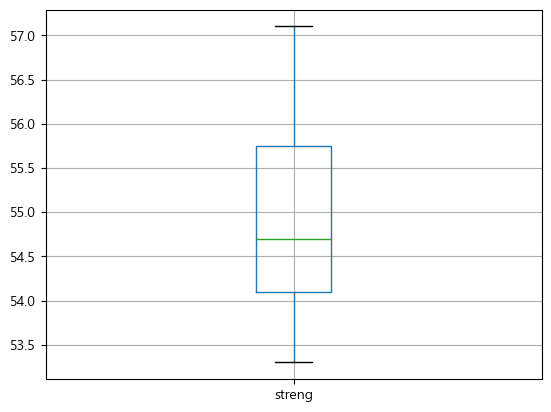

In [38]:
# boxplot
df.boxplot()